### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [3]:
data=pd.read_excel("C:\\Users\\mahen\\Downloads\\financial_loan_data_excel.xlsx")
a=pd.DataFrame(data)
print(a)

            id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat Technology Inc     C           RE

### Metadata of data

In [3]:
print("Rows,Columns:", a.shape)

Rows,Columns: (38576, 24)


In [4]:
print("Rows: ",a.shape[0])

Rows:  38576


In [5]:
print("Columns: ",a.shape[1])

Columns:  24


In [6]:
a.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  datetime64[us]
 9   last_payment_date      38576 non-null  datetime64[us]
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  datetime64[us]
 12  member_id              38576 non-null  int64         
 13  purpose     

### Data Types

In [7]:
a.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [8]:
a.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Total Loan Applications

In [9]:
Total_Loan_Applications=a['id'].count()
Total_Loan_Applications_Thousands=Total_Loan_Applications/1000
print("Total_Loan_Applications (in Thousands): {:.1f}K".format(Total_Loan_Applications_Thousands))

Total_Loan_Applications (in Thousands): 38.6K


### MTD Total Loan Applications

In [10]:
Latest_Issue_Date=a['issue_date'].max()
Latest_Year=Latest_Issue_Date.year
Latest_Month=Latest_Issue_Date.month
Mtd_Data=a[(a['issue_date'].dt.year==Latest_Year) & (a['issue_date'].dt.month==Latest_Month)]
Mtd_Loan_Applications=Mtd_Data['id'].count()
Mtd_Loan_Applications_Thousands=Mtd_Loan_Applications/1000
print(f"MTD Loan Applications (for {Latest_Issue_Date.strftime('%B %Y')}): {Mtd_Loan_Applications_Thousands:.1f}K")

MTD Loan Applications (for December 2021): 4.3K


### PMTD Total Loan Applications

In [11]:
Latest_Issue_Date=a['issue_date'].max()
Latest_Year=Latest_Issue_Date.year
Latest_Month=Latest_Issue_Date.month
if Latest_Month==1:
  Previous_Month=12
  Previous_Year=Latest_Year-1
else:
  Previous_Month=Latest_Month-1
  Previous_Year=Latest_Year
PMtd_Data=a[(a['issue_date'].dt.year==Previous_Year) & (a['issue_date'].dt.month==Previous_Month)]
PMtd_Loan_Applications=PMtd_Data['id'].count()
PMtd_Loan_Applications_Thousands=PMtd_Loan_Applications/1000
print(f"PMTD Loan Applications (for {PMtd_Data['issue_date'].max().strftime('%B %Y')}): {PMtd_Loan_Applications_Thousands:.1f}K")

PMTD Loan Applications (for November 2021): 4.0K


### MOM Total Loan Application Percentage

In [12]:
MOM_Total_Loan_Application_Percengtage=(Mtd_Loan_Applications_Thousands-PMtd_Loan_Applications_Thousands)/PMtd_Loan_Applications_Thousands*100
print("MOM Total Loan Application (in Percentage): {:.1f}%".format(MOM_Total_Loan_Application_Percengtage))

MOM Total Loan Application (in Percentage): 6.9%


### Total Funded Amount

In [13]:
Total_Funded_Amount=a['loan_amount'].sum()
Total_Funded_Amount_Millions=Total_Funded_Amount/1000000
print("Total Funded Amount (in Millions): ${:.1f}M".format(Total_Funded_Amount_Millions))

Total Funded Amount (in Millions): $435.8M


### MTD Total Funded Amount

In [14]:
Latest_Issued_Date=a['issue_date'].max()
Issued_Year=Latest_Issued_Date.year
Issued_Month=Latest_Issued_Date.month
MTD_Amount=a[(a['issue_date'].dt.year==Issued_Year) & (a['issue_date'].dt.month==Issued_Month)]
MTD_Total_Funded_Amount=MTD_Amount['loan_amount'].sum()
MTD_Total_Funded_Amount_Millions=MTD_Total_Funded_Amount/1000000
print(f"MTD Total Funded Amount (for {Latest_Issued_Date.strftime('%B %Y')}): ${MTD_Total_Funded_Amount_Millions:.1f}M")

MTD Total Funded Amount (for December 2021): $54.0M


### PMTD Total Funded Amount

In [15]:
Latest_Issue_Date=a['issue_date'].max()
Latest_Year=Latest_Issue_Date.year
Latest_Month=Latest_Issue_Date.month
if Latest_Month==1:
  Previous_Month=12
  Previous_Year=Latest_Year-1
else:
  Previous_Month=Latest_Month-1
  Previous_Year=Latest_Year
PMtd_Data=a[(a['issue_date'].dt.year==Previous_Year) & (a['issue_date'].dt.month==Previous_Month)]
PMtd_Total_Funded_Amount=PMtd_Data['loan_amount'].sum()
PMtd_Total_Funded_Amount_Millions=PMtd_Total_Funded_Amount/1000000
print(f"PMtd Total Funded Amount (for {PMtd_Data['issue_date'].max().strftime('%B %Y')}): ${PMtd_Total_Funded_Amount_Millions:.1f}M")

PMtd Total Funded Amount (for November 2021): $47.8M


### MOM Total Funded Amount Percentage

In [16]:
Mom_Total_Funded_Amount_Percentage=(MTD_Total_Funded_Amount_Millions-PMtd_Total_Funded_Amount_Millions)/PMtd_Total_Funded_Amount_Millions*100
print("Mom Total Funded Amount (in Percentage): {:.1f}%".format(Mom_Total_Funded_Amount_Percentage))

Mom Total Funded Amount (in Percentage): 13.0%


### Total Amount Received

In [17]:
Total_Amount_Received=a['total_payment'].sum()
Total_Amount_Received_Millions=Total_Amount_Received/1000000
print("Total Amount Received (in Millions): ${:.1f}M:".format(Total_Amount_Received_Millions))

Total Amount Received (in Millions): $473.1M:


### MTD Total Amount Received

In [18]:
Latest_Issued_Date=a['issue_date'].max()
Issued_Year=Latest_Issued_Date.year
Issued_Month=Latest_Issued_Date.month
MTD_Amount_Received=a[(a['issue_date'].dt.year==Issued_Year) & (a['issue_date'].dt.month==Issued_Month)]
MTD_Total_Amount_Received=MTD_Amount_Received['total_payment'].sum()
MTD_Total_Amount_Received_Millions=MTD_Total_Amount_Received/1000000
print(f"MTD Total Amount Received (for {Latest_Issue_Date.strftime('%B %Y')}): ${MTD_Total_Amount_Received_Millions:.1f}M")

MTD Total Amount Received (for December 2021): $58.1M


### PMTD Total Amount Received

In [19]:
Latest_Issued_Date=a['issue_date'].max()
Issued_Year=Latest_Issued_Date.year
Issued_Month=Latest_Issued_Date.month
if Issued_Month==1:
    Previous_Month=12
    Previous_Year=Issued_Year-1
else:
    Previous_Month=Issued_Month-1
    Previous_Year=Issued_Year
PMTD_Amount_Received=a[(a['issue_date'].dt.year==Previous_Year) & (a['issue_date'].dt.month==Previous_Month)]
PMTD_Total_Amount_Received=PMTD_Amount_Received['total_payment'].sum()
PMTD_Total_Amount_Received_Millions=PMTD_Total_Amount_Received/1000000
print(f"PMTD Total Amount Received (for {PMTD_Amount_Received['issue_date'].max().strftime('%B %Y')}): ${PMTD_Total_Amount_Received_Millions:.1f}M")

PMTD Total Amount Received (for November 2021): $50.1M


### MOM Total Amount Received Percentage

In [20]:
MOM_Total_Amount_Received_Percentage=(MTD_Total_Amount_Received_Millions-PMTD_Total_Amount_Received_Millions)/PMTD_Total_Amount_Received_Millions*100
print("MOM Total Amount Received (in Percentage): {:.1f}%".format(MOM_Total_Amount_Received_Percentage))

MOM Total Amount Received (in Percentage): 15.8%


### Average Interest Rate

In [21]:
Avg_Interest_Rate=a['int_rate'].mean()
Avg_Interest_Rate_Percentage=Avg_Interest_Rate*100
print("Avg Interest Rate (in Percentage): {:.2f}%".format(Avg_Interest_Rate_Percentage))

Avg Interest Rate (in Percentage): 12.05%


### MTD Average Interest Rate

In [22]:
Latest_Issued_Date=a['issue_date'].max()
Latest_Year=Latest_Issued_Date.year
Latest_Month=Latest_Issued_Date.month
MTD_Average_Interest=a[(a['issue_date'].dt.year==Latest_Year) & (a['issue_date'].dt.month==Latest_Month)]
MTD_Average_Interest_Rate=MTD_Average_Interest['int_rate'].mean()
MTD_Average_Interest_Rate_Percentage=MTD_Average_Interest_Rate * 100
print(f"MTD Average Interest Rate (for {Latest_Issued_Date.strftime('%B %Y')}): {MTD_Average_Interest_Rate_Percentage:.1f}%")

MTD Average Interest Rate (for December 2021): 12.4%


### PMTD Average Interest Rate

In [23]:
Latest_Issued_Date=a['issue_date'].max()
Issued_Year=Latest_Issued_Date.year
Issued_Month=Latest_Issued_Date.month
if Issued_Month==1:
    Previous_Month=12
    Previous_Year=Issued_Year-1
else:
    Previous_Month=Issued_Month-1
    Previous_Year=Issued_Year
PMTD_Average_Interest=a[(a['issue_date'].dt.year==Previous_Year) & (a['issue_date'].dt.month==Previous_Month)]
PMTD_Average_Interest_Rate=PMTD_Average_Interest['int_rate'].mean()
PMTD_Average_Interest_Rate_Percentage=PMTD_Average_Interest_Rate * 100
print(f"PMTD Average Interest Rate (for {PMTD_Average_Interest['issue_date'].max().strftime('%B %Y')}): {PMTD_Average_Interest_Rate_Percentage:.1f}%")

PMTD Average Interest Rate (for November 2021): 11.9%


### MOM Average Interest Rate Percentage

In [24]:
MOM_Average_Interest_Rate_Percentage=(MTD_Average_Interest_Rate_Percentage-PMTD_Average_Interest_Rate_Percentage)/PMTD_Average_Interest_Rate_Percentage*100
print("MOM Average Interest Rate (in Percentage): {:.1f}%".format(MOM_Average_Interest_Rate_Percentage))

MOM Average Interest Rate (in Percentage): 3.5%


### Average DTI

In [25]:
Average_DTI=a['dti'].mean()
Average_DTI_Percentage=Average_DTI * 100
print("Average DTI (in Percentage): {:.2f}%".format(Average_DTI_Percentage))

Average DTI (in Percentage): 13.33%


### MTD Average DTI

In [26]:
Latest_Issued_Date=a['issue_date'].max()
Latest_Year=Latest_Issued_Date.year
Latest_Month=Latest_Issued_Date.month
MTD_Average=a[(a['issue_date'].dt.year==Latest_Year) & (a['issue_date'].dt.month==Latest_Month)]
MTD_Average_DTI=MTD_Average['dti'].mean()
MTD_Average_DTI_Percentage=MTD_Average_DTI * 100
print(f"MTD Average DTI (for {Latest_Issued_Date.strftime('%B %Y')}): {MTD_Average_DTI_Percentage:.1f}%")

MTD Average DTI (for December 2021): 13.7%


### PMTD Average DTI

In [27]:
Latest_Issued_Date=a['issue_date'].max()
Issued_Year=Latest_Issued_Date.year
Issued_Month=Latest_Issued_Date.month
if Issued_Month==1:
    Previous_Month=12
    Previous_Year=Issued_Year-1
else:
    Previous_Month=Issued_Month-1
    Previous_Year=Issued_Year
PMTD_Average=a[(a['issue_date'].dt.year==Previous_Year) & (a['issue_date'].dt.month==Previous_Month)]
PMTD_Average_DTI=PMTD_Average['dti'].mean()
PMTD_Average_DTI_Percentage=PMTD_Average_DTI * 100
print(f"PMTD Average DTI (for {PMTD_Average['issue_date'].max().strftime('%B %Y')}): {PMTD_Average_DTI_Percentage:.1f}%")

PMTD Average DTI (for November 2021): 13.3%


### MOM Average DTI Percentage

In [28]:
MOM_Average_DTI_Percentage=(MTD_Average_DTI_Percentage-PMTD_Average_DTI_Percentage)/PMTD_Average_DTI_Percentage*100
print("MOM Average DTI (in Percentage): {:.1f}%".format(MOM_Average_DTI_Percentage))

MOM Average DTI (in Percentage): 2.7%


### Good Loan Metrics

In [29]:
Good_Loans=a[a['loan_status'].isin(['Fully Paid','Current'])]
Good_Loan_Applications=Good_Loans['id'].count()
Good_Loan_Applications_Thousands=Good_Loan_Applications/1000

Good_Loan_Funded_Amount=Good_Loans['loan_amount'].sum()
Good_Loan_Funded_Amount_Millions=Good_Loan_Funded_Amount/1000000

Good_Loan_Total_Received=Good_Loans['total_payment'].sum()
Good_Loan_Total_Received_Millions=Good_Loan_Total_Received/1000000

Good_Loan_Issued_Count=Good_Loans['id'].count()
Total_Loan_Applications=a['id'].count()
Good_Loan_Issued_Percentage=Good_Loan_Issued_Count/Total_Loan_Applications * 100

print("Good Loan Applications (in Thousands): {:.1f}K".format(Good_Loan_Applications_Thousands))
print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(Good_Loan_Funded_Amount_Millions))
print("Good Loan Total Received (in Millions): ${:.1f}M".format(Good_Loan_Total_Received_Millions))
print("Good Loan Issued (in Percentage): {:.1f}%".format(Good_Loan_Issued_Percentage))

Good Loan Applications (in Thousands): 33.2K
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Total Received (in Millions): $435.8M
Good Loan Issued (in Percentage): 86.2%


### Bad Loan Metrics

In [30]:
Bad_Loans=a[a['loan_status'].isin(['Charged Off'])]
Bad_Loan_Applications=Bad_Loans['id'].count()
Bad_Loan_Applications_Thousands=Bad_Loan_Applications/1000

Bad_Loan_Funded_Amount=Bad_Loans['loan_amount'].sum()
Bad_Loan_Funded_Amount_Millions=Bad_Loan_Funded_Amount/1000000

Bad_Loan_Total_Received=Bad_Loans['total_payment'].sum()
Bad_Loan_Total_Received_Millions=Bad_Loan_Total_Received/1000000

Bad_Loan_Issued_Count=Bad_Loans['id'].count()
Total_Loan_Applications=a['id'].count()
Bad_Loan_Issued_Percentage=Bad_Loan_Issued_Count/Total_Loan_Applications * 100

print("Bad Loan Applications (in Thousands): {:.1f}K".format(Bad_Loan_Applications_Thousands))
print("Bad Loan Funded Amount (in Millions): ${:.2f}M".format(Bad_Loan_Funded_Amount_Millions))
print("Bad Loan Total Received (in Millions): ${:.1f}M".format(Bad_Loan_Total_Received_Millions))
print("Bad Loan Issued (in Percentage): {:.1f}% ".format(Bad_Loan_Issued_Percentage))

Bad Loan Applications (in Thousands): 5.3K
Bad Loan Funded Amount (in Millions): $65.53M
Bad Loan Total Received (in Millions): $37.3M
Bad Loan Issued (in Percentage): 13.8% 


### Monthly Trends by Issue Date for Total Funded Amount

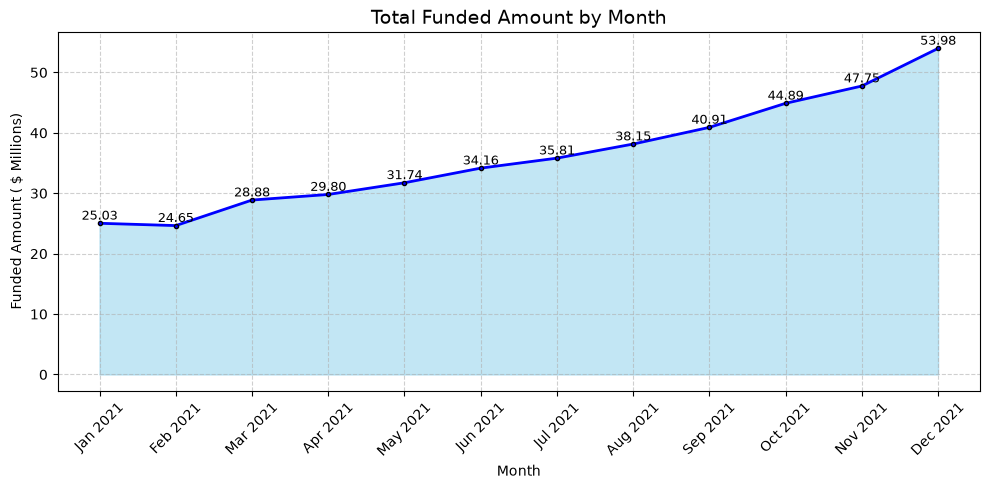

In [45]:
monthly_funded = (
    a.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color='skyblue', alpha=0.5)
plt.plot(monthly_funded['month_name'], monthly_funded['loan_amount_millions'], color='blue', linewidth=2,marker='.',mec='black')

for i, row in monthly_funded.iterrows():
    plt.text(i, row['loan_amount_millions'] + 0.1, f"{row['loan_amount_millions']:.2f}",
              ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount ( $ Millions)')
plt.xticks(ticks=range(len(monthly_funded)), labels=monthly_funded['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Amount Received

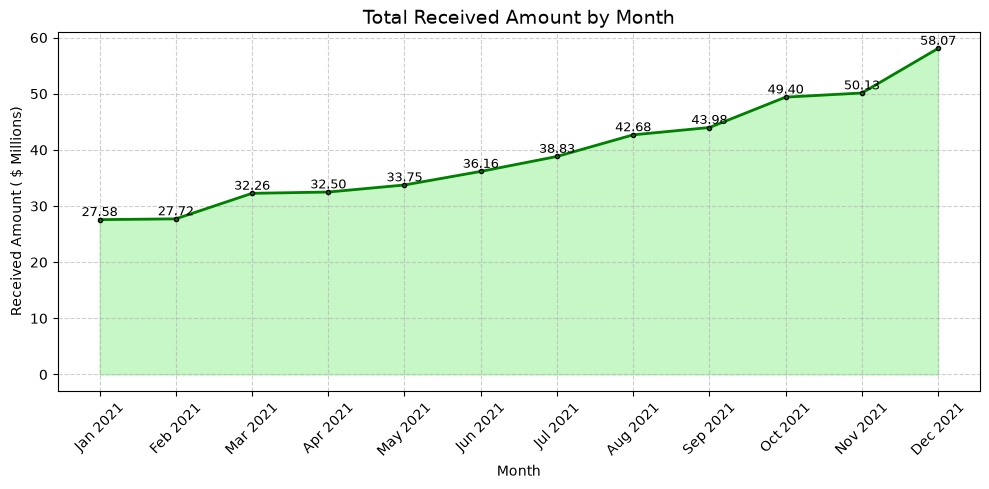

In [46]:
monthly_received = (
    a.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_received['month_name'], monthly_received['received_amount_millions'], color='lightgreen', alpha=0.5)
plt.plot(monthly_received['month_name'], monthly_received['received_amount_millions'], color='green', linewidth=2,marker='.',mec='black')

for i, row in monthly_received.iterrows():
    plt.text(i, row['received_amount_millions'] + 0.1, f"{row['received_amount_millions']:.2f}",
              ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount ( $ Millions)')
plt.xticks(ticks=range(len(monthly_received)), labels=monthly_received['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Loan Applications

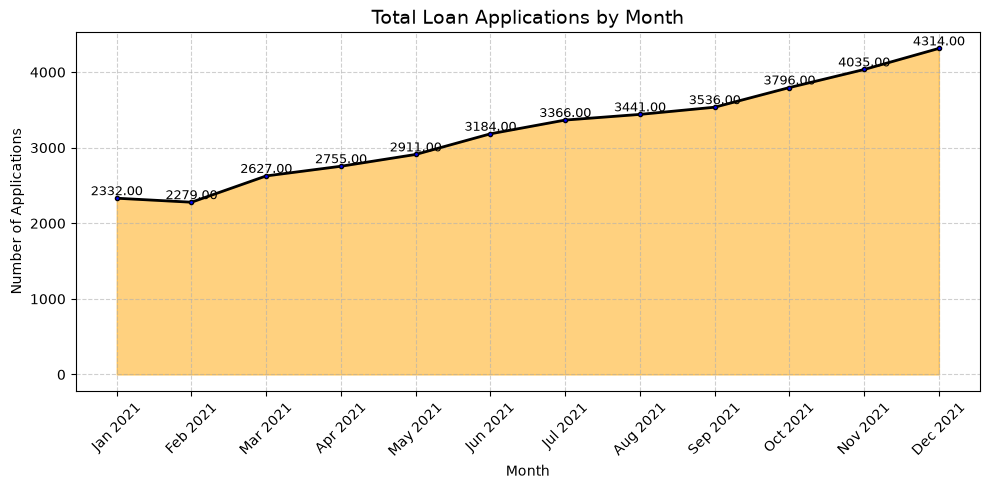

In [50]:
monthly_applications = (
    a.sort_values('issue_date')
    .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['id']
    .count()
    .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_applications['month_name'], monthly_applications['loan_applications_count'], color='orange', alpha=0.5)
plt.plot(monthly_applications['month_name'], monthly_applications['loan_applications_count'], color='black', linewidth=2,marker='.',mfc='blue')

for i, row in monthly_applications.iterrows():
    plt.text(i, row['loan_applications_count'] + 0.1, f"{row['loan_applications_count']:.2f}",
              ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(ticks=range(len(monthly_applications)), labels=monthly_applications['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

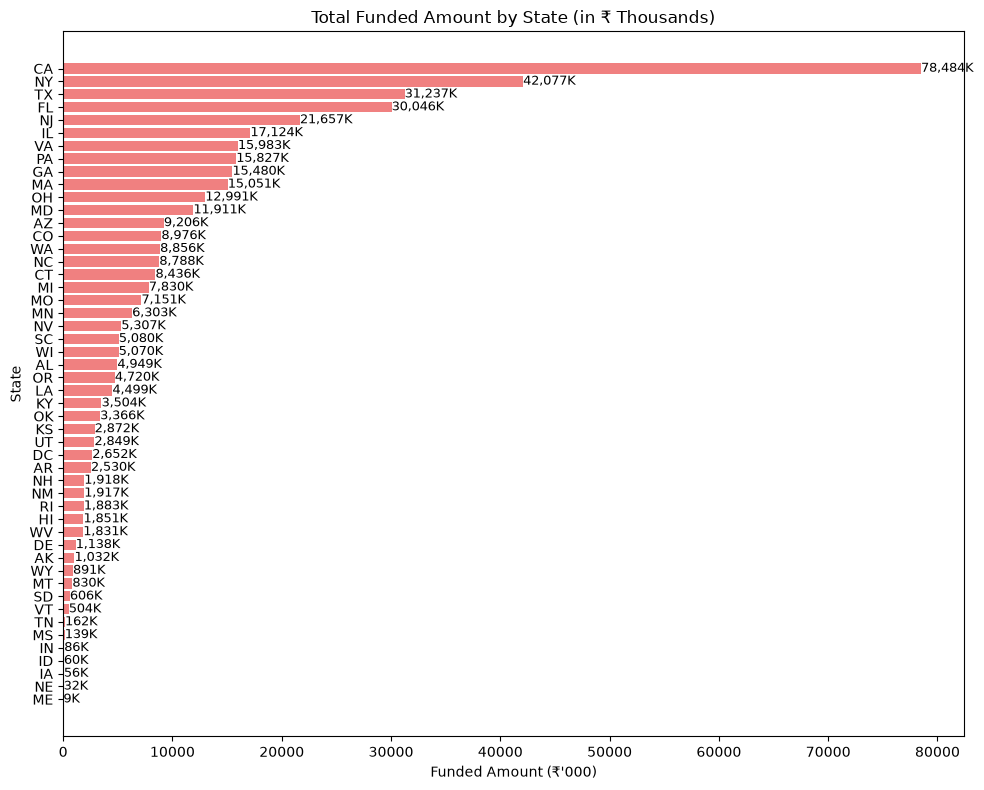

In [53]:
state_funding = a.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10, 8))

bars = plt.barh(
    state_funding_thousands.index,
    state_funding_thousands.values,
    color='lightcoral'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}K',
        va='center',
        fontsize=9
    )

plt.title('Total Funded Amount by State (in ₹ Thousands)')
plt.xlabel("Funded Amount (₹\'000)")
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Received Amount

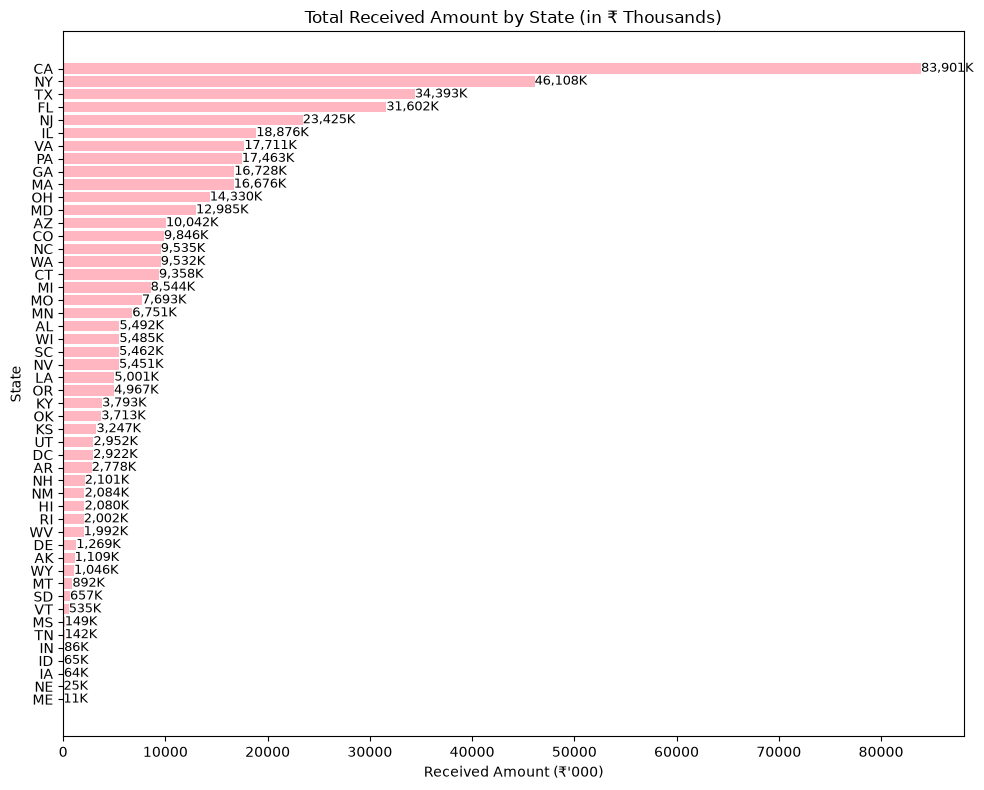

In [54]:
state_Received = a.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_Received_thousands = state_Received / 1000

plt.figure(figsize=(10, 8))

bars = plt.barh(
    state_Received_thousands.index,
    state_Received_thousands.values,
    color='lightpink'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}K',
        va='center',
        fontsize=9
    )

plt.title('Total Received Amount by State (in ₹ Thousands)')
plt.xlabel("Received Amount (₹\'000)")
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Loan Applications

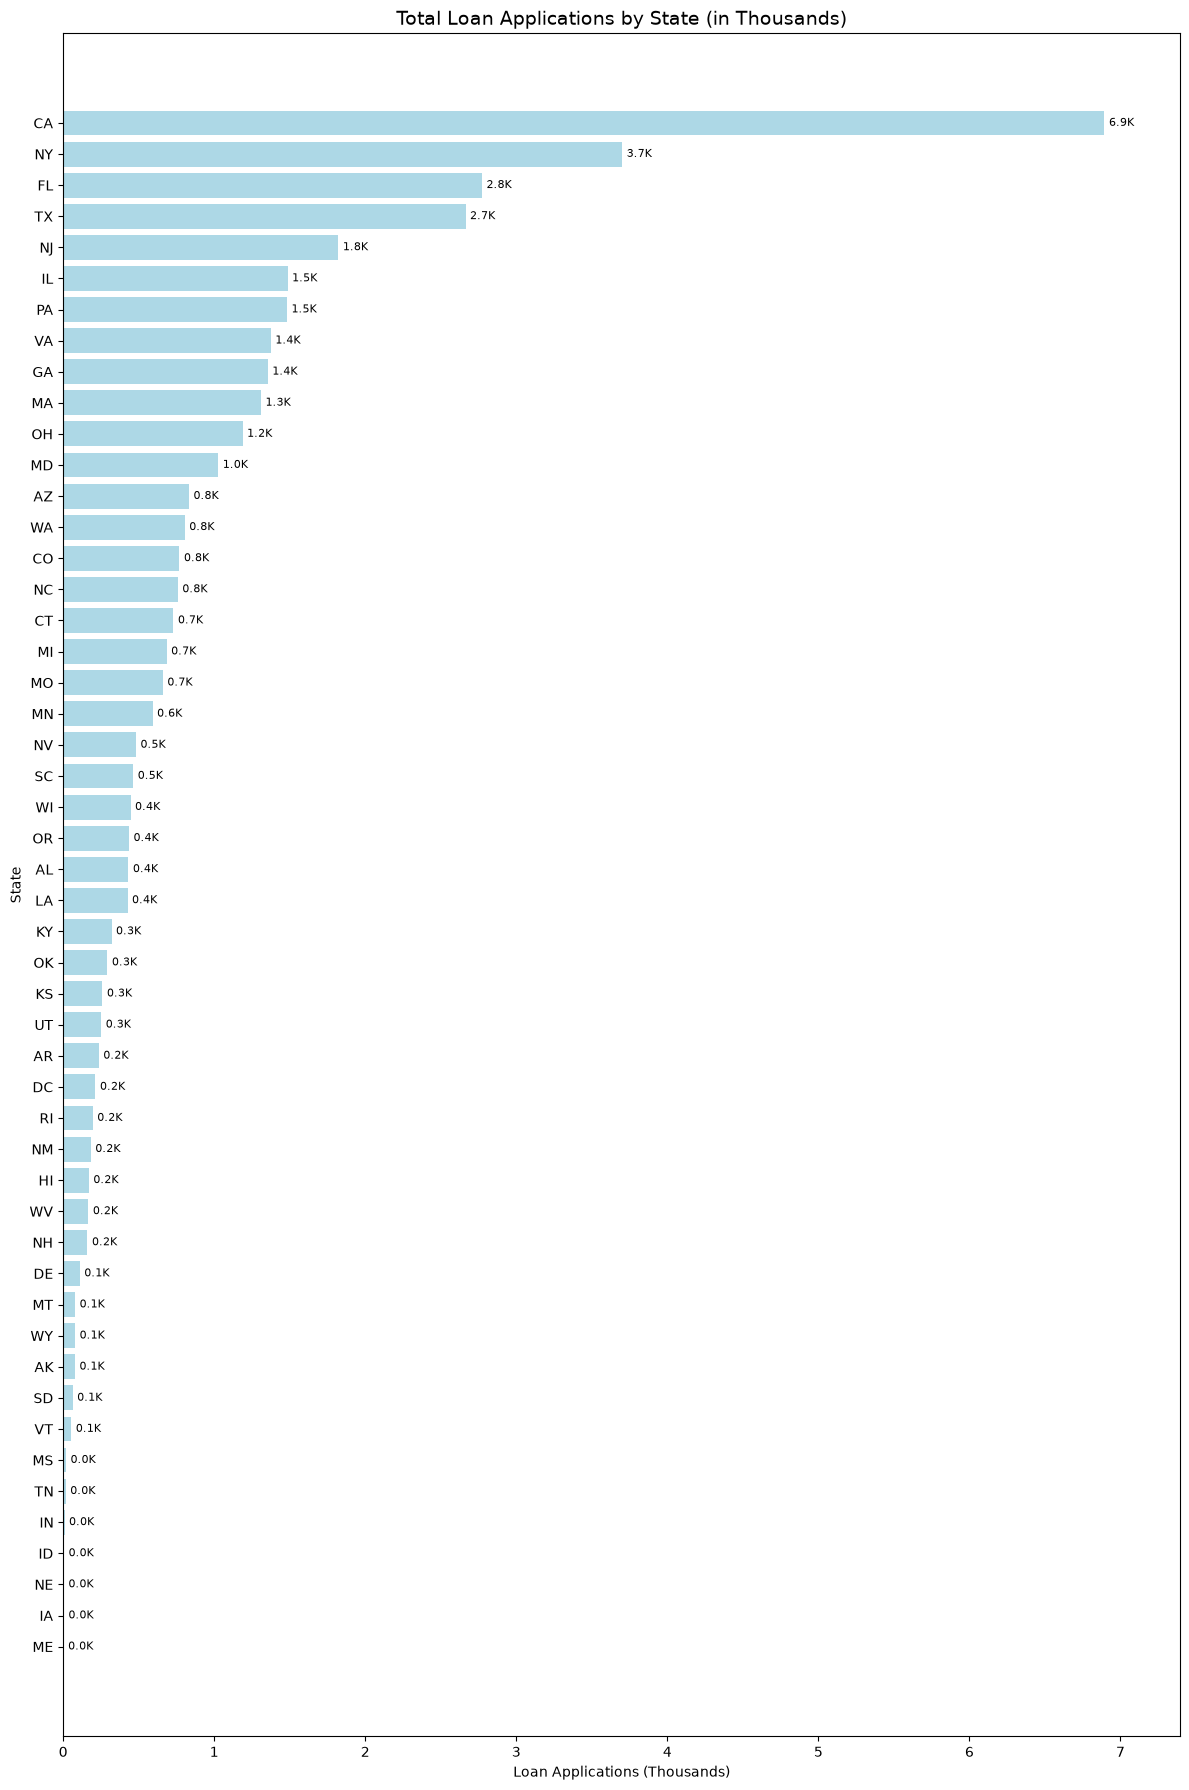

In [66]:
state_total_loan = (
    a.groupby('address_state')['id']
    .count()
    .sort_values(ascending=True)
)
state_total_loan_thousands = state_total_loan / 1000
plt.figure(figsize=(12, 18))
bars = plt.barh(
    state_total_loan_thousands.index,
    state_total_loan_thousands.values,
    color='lightblue'
)
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.03,                     
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}K",
        va='center',
        fontsize=8
    )
plt.title("Total Loan Applications by State (in Thousands)", fontsize=14)
plt.xlabel("Loan Applications (Thousands)")
plt.ylabel("State")
plt.xlim(0, state_total_loan_thousands.max() + 0.5)
plt.tight_layout()
plt.show()

### Loan Term Analysis by Total Funded Amount

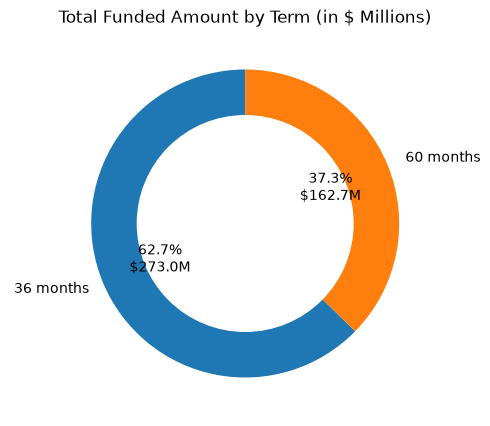

In [68]:
term_funding_millions = a.groupby('term')['loan_amount'].sum() / 1000000
plt.figure(figsize=(5, 5))
plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${(p * sum(term_funding_millions) / 100):.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Funded Amount by Term (in $ Millions)")
plt.show()

### Loan Term Analysis by Total Amount Received

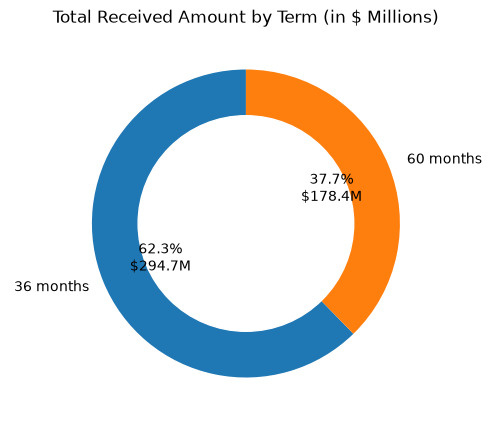

In [69]:
term_received_millions = a.groupby('term')['total_payment'].sum() / 1000000
plt.figure(figsize=(5, 5))
plt.pie(
    term_received_millions,
    labels=term_received_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${(p * sum(term_received_millions) / 100):.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Received Amount by Term (in $ Millions)")
plt.show()

### Loan Term Analysis by Total Loan Applications

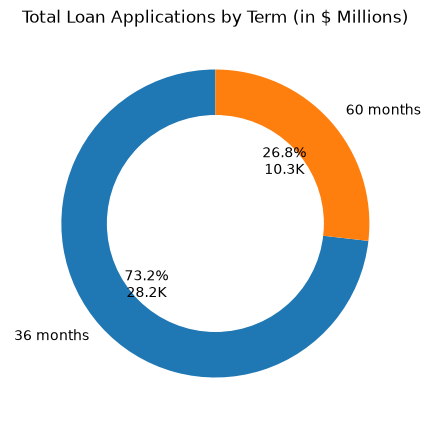

In [75]:
term_loan = a.groupby('term')['id'].count() / 1000
plt.figure(figsize=(5, 5))
plt.pie(
    term_loan,
    labels=term_loan.index,
    autopct=lambda p: f"{p:.1f}%\n{(p * sum(term_loan) / 100):.1f}K",
    startangle=90,
    wedgeprops={'width': 0.4}
)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Loan Applications by Term (in $ Millions)")
plt.show()

### Employee Length by Total Funded Amount¶

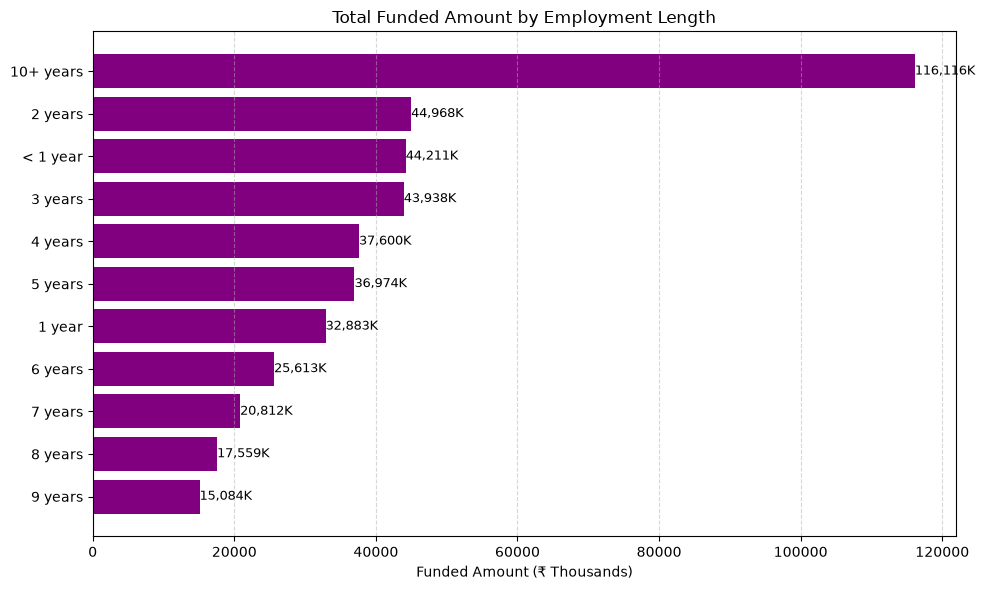

In [77]:
emp_funding = a.groupby('emp_length')['loan_amount'].sum().sort_values() / 1000
plt.figure(figsize=(10, 6))
bars = plt.barh(emp_funding.index, emp_funding, color='purple')
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}K",
        va='center',
        fontsize=9
    )
plt.xlabel("Funded Amount (₹ Thousands)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Employee Length by Total Amount Received

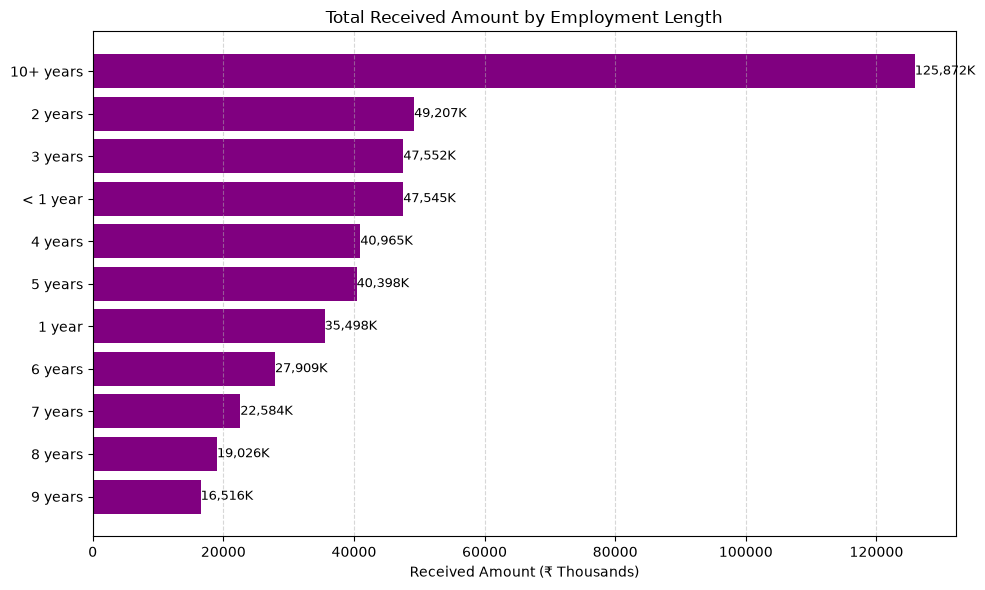

In [78]:
emp_received = a.groupby('emp_length')['total_payment'].sum().sort_values() / 1000
plt.figure(figsize=(10, 6))
bars = plt.barh(emp_received.index, emp_received, color='purple')
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}K",
        va='center',
        fontsize=9
    )
plt.xlabel("Received Amount (₹ Thousands)")
plt.title("Total Received Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Employee Length by Total Loan Applications

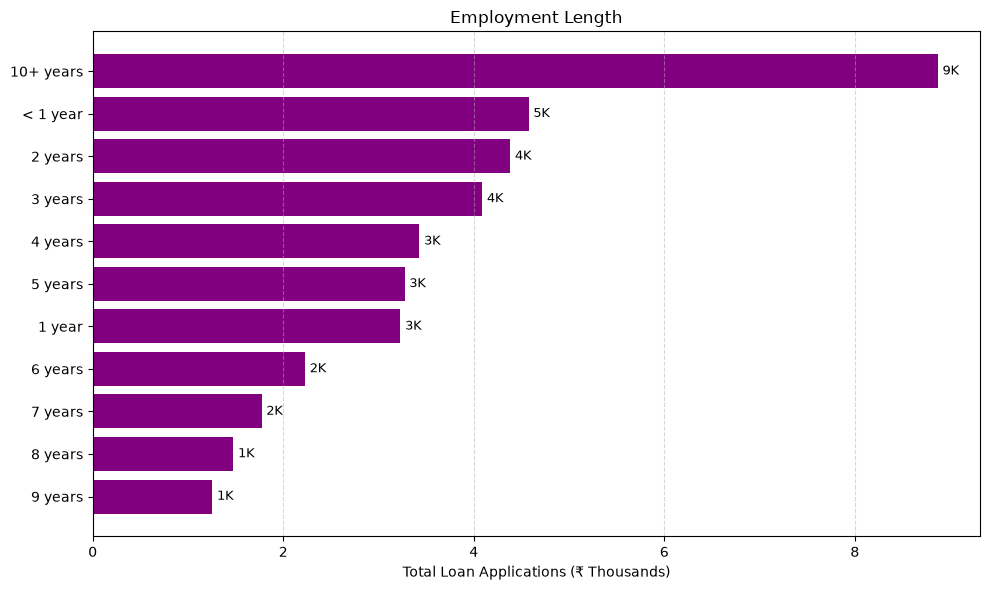

In [80]:
emp_loan = a.groupby('emp_length')['id'].count().sort_values() / 1000
plt.figure(figsize=(10, 6))
bars = plt.barh(emp_loan.index, emp_loan, color='purple')
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.0f}K",
        va='center',
        fontsize=9
    )
plt.xlabel("Total Loan Applications (₹ Thousands)")
plt.title("Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Purpose by Total Funded Amount

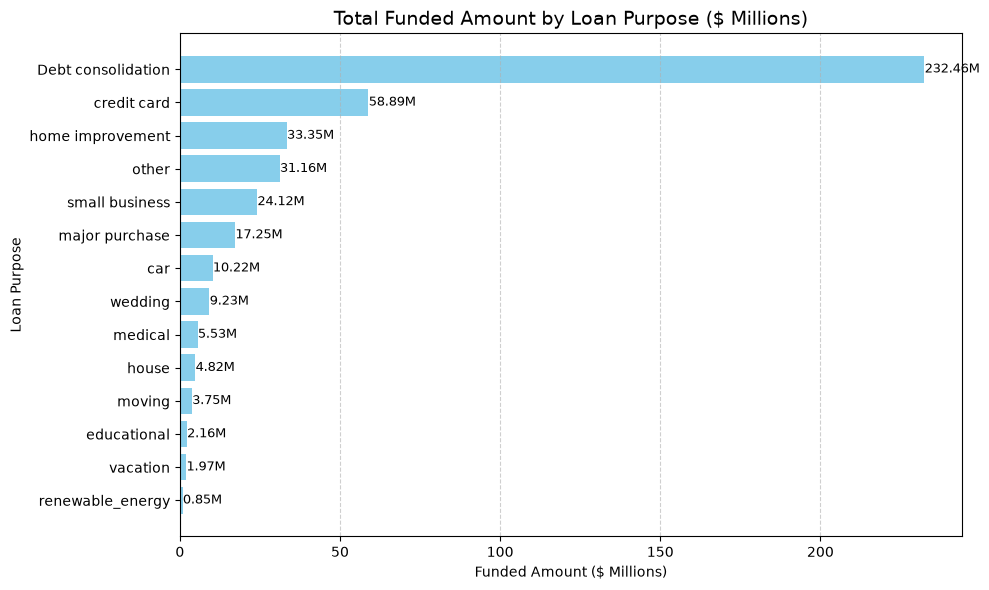

In [8]:
purpose_funding_millions = (
    a.groupby('purpose')['loan_amount']
      .sum()
      .sort_values() / 1000000
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    purpose_funding_millions.index,
    purpose_funding_millions.values,
    color='skyblue'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}M',
        va='center',
        fontsize=9
    )

plt.title('Total Funded Amount by Loan Purpose ($ Millions)', fontsize=14)
plt.xlabel('Funded Amount ($ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Loan Purpose by Total Received Amount

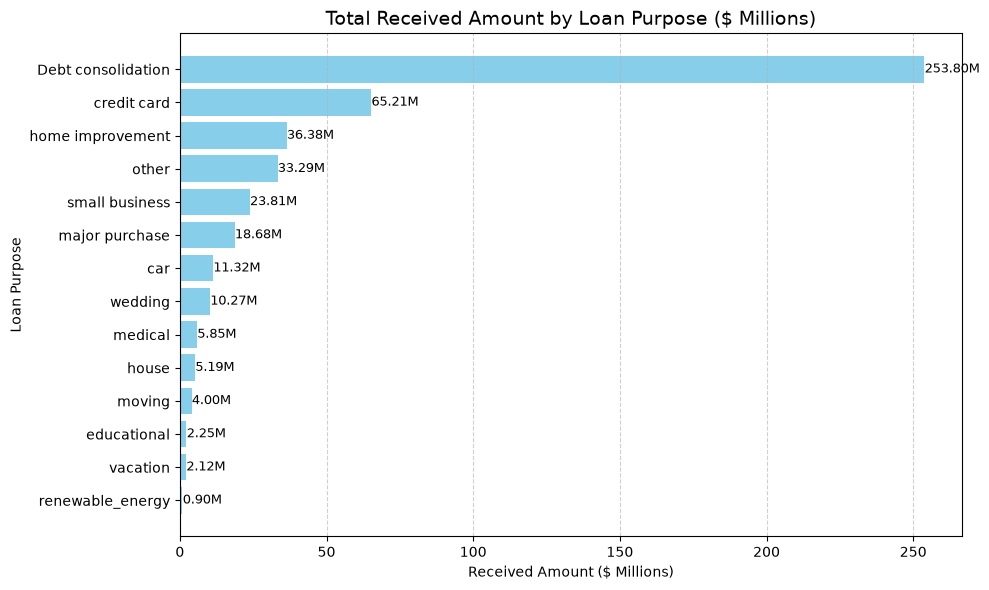

In [7]:
purpose_Received_millions = (
    a.groupby('purpose')['total_payment']
      .sum()
      .sort_values() / 1000000
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    purpose_Received_millions.index,
    purpose_Received_millions.values,
    color='skyblue'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}M',
        va='center',
        fontsize=9
    )

plt.title('Total Received Amount by Loan Purpose ($ Millions)', fontsize=14)
plt.xlabel('Received Amount ($ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Total Loan Applications by Loan Purpose 

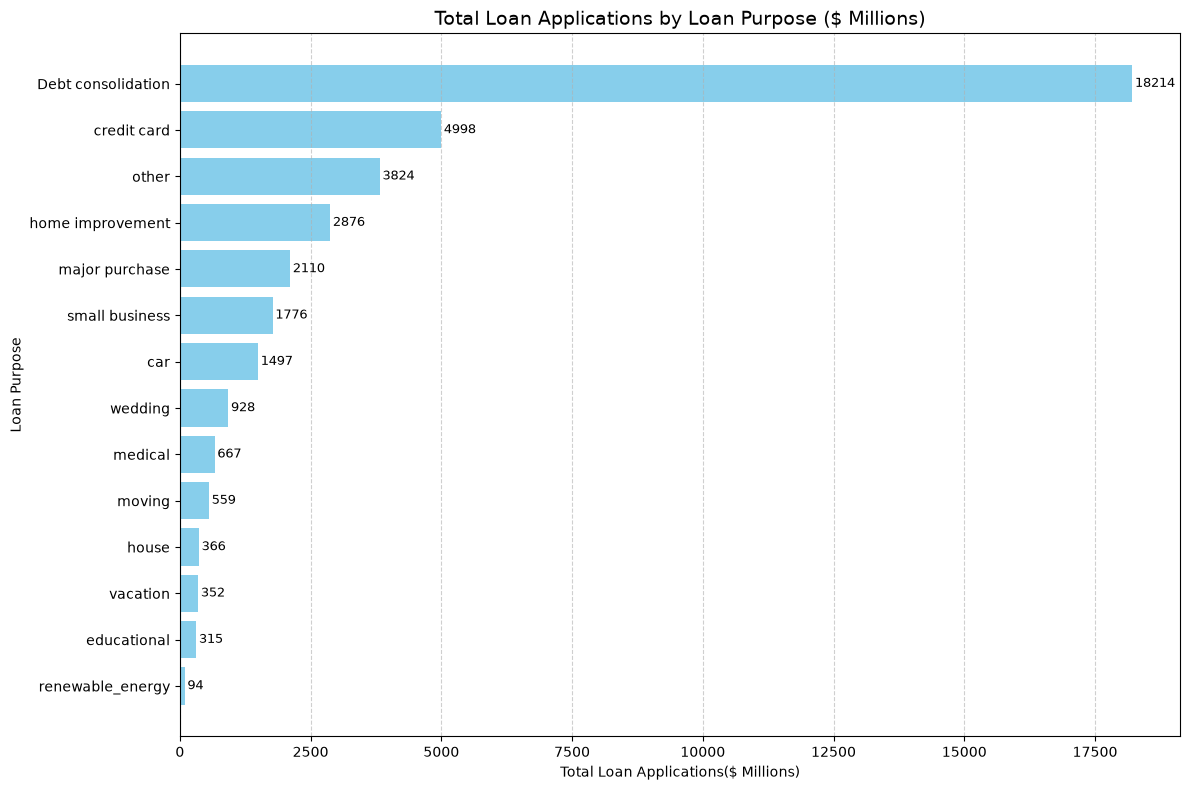

In [17]:
purpose_Total_Loans = (
    a.groupby('purpose')['id']
      .count()
      .sort_values()
)
plt.figure(figsize=(12, 8))
bars = plt.barh(
    purpose_Total_Loans.index,
    purpose_Total_Loans.values,
    color='skyblue'
)
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 50,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        fontsize=9
    )
plt.title('Total Loan Applications by Loan Purpose ($ Millions)', fontsize=14)
plt.xlabel('Total Loan Applications($ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Home Ownership by Total Funded Amount

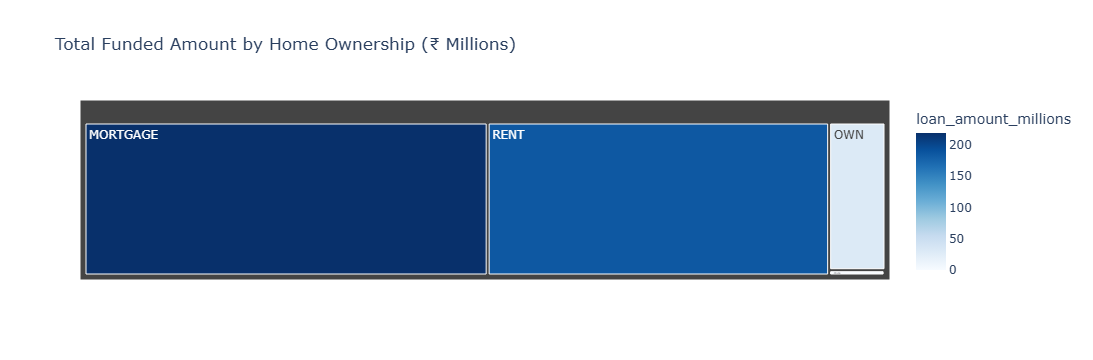

In [18]:
home_funding = a.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1000000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership (₹ Millions)'
)

fig.show()

### Home Ownership by Total Amount Received

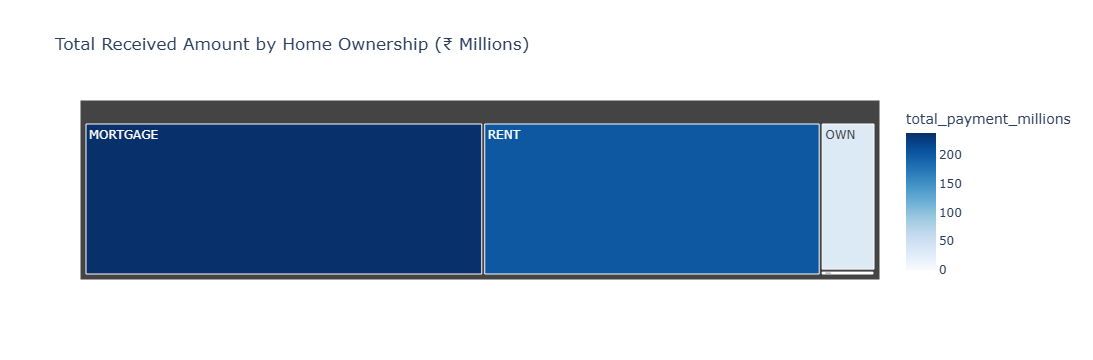

In [21]:
home_received = a.groupby('home_ownership')['total_payment'].sum().reset_index()
home_received['total_payment_millions'] = home_received['total_payment'] / 1000000
fig = px.treemap(
    home_received,
    path=['home_ownership'],
    values='total_payment_millions',
    color='total_payment_millions',
    color_continuous_scale='Blues',
    title='Total Received Amount by Home Ownership (₹ Millions)'
)
fig.show()

### Home Ownership by Total Loan Applications

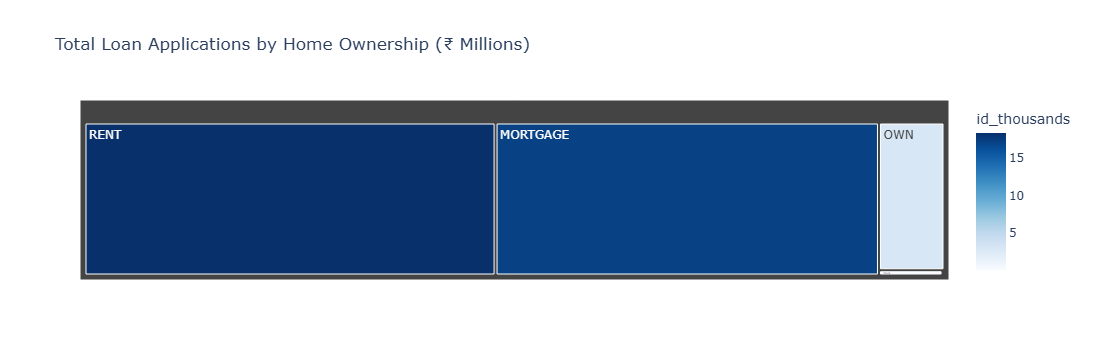

In [26]:
home_total_loan= a.groupby('home_ownership')['id'].count().reset_index()
home_total_loan['id_thousands'] = home_total_loan['id'] / 1000
fig = px.treemap(
    home_total_loan,
    path=['home_ownership'],
    values='id_thousands',
    color='id_thousands',
    color_continuous_scale='Blues',
    title='Total Loan Applications by Home Ownership (₹ Millions)'
)
fig.show()